In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style='whitegrid')

# Cargar el dataset de Brasil
df_brasil = pd.read_excel("dados_brutos.xlsx")

# 1. Ver las primeras 5 filas
print("--- Primeras filas del dataset de Energía ---")
display(df_brasil.head())

# 2. Ver la estrucutra, nombres de columnas y valores nulos
print("--- Informacion del Dataset ---")
df_brasil.info()



--- Primeras filas del dataset de Energía ---


,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0
3,20140401,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,10.0
4,20140501,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


--- Informacion del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  str    
 2   Sistema               285499 non-null  str    
 3   UF                    285499 non-null  str    
 4   Setor Econômico - N1  285499 non-null  str    
 5   Setor Econômico - N2  285499 non-null  str    
 6   Setor Econômico - N3  285499 non-null  str    
 7   Tipo Tensão - N1      285499 non-null  str    
 8   Tipo Tensão - N2      285499 non-null  str    
 9   Tipo Tensão - N3      285499 non-null  str    
 10  Faixa de Consumo N1   285499 non-null  str    
 11  Faixa de Consumo N2   285499 non-null  str    
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), str(11

In [3]:
# 1. Limpieza de nulos
# Eliminamos las filas donde NO hay datos de Consumo 
df_brasil.dropna(subset=['Consumo'], inplace=True)

# 2. Conversión de fechas
# Convertir el int64 a string temporalmente, y luego le pedimos a pandas que lo convierta a formato Fecha
df_brasil['Data'] = pd.to_datetime(df_brasil['Data'].astype(str), format='%Y%m%d', errors='coerce')

# 3. Establecer la fecha como indice temporal y ordenar
df_brasil.set_index('Data', inplace=True)
df_brasil.sort_index(inplace=True)

# 4. Verificación de la base de operaciones
print("--- Datos listos para Series Temporales ---")
display(df_brasil.head())

--- Datos listos para Series Temporales ---


,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
Data,,,,,,,,,,,,,
2014-01-01,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2014-01-01,Cativo,Norte Interligado,TO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,B - Baixa Tensão,TOTAL,TOTAL,Convencional,401-500 kWh,6843.0,3041.0
2014-01-01,Cativo,Sudeste / Centro-Oeste,MS,Comercial,Comercial N2,TOTAL,A - Alta Tensão,"A-4 - 2,3 a 25 kV",TOTAL,Não Aplicável,Não Aplicável,435.0,13864.0
2014-01-01,Cativo,Norte Interligado,TO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,B - Baixa Tensão,TOTAL,TOTAL,Convencional,501-1000 kWh,8614.0,5660.0
2014-01-01,Cativo,Norte Interligado,TO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,B - Baixa Tensão,TOTAL,TOTAL,Convencional,> 1000 kWh,1714.0,2762.0


# EDA de Energía (Distribuciones y Tendencias Generales)

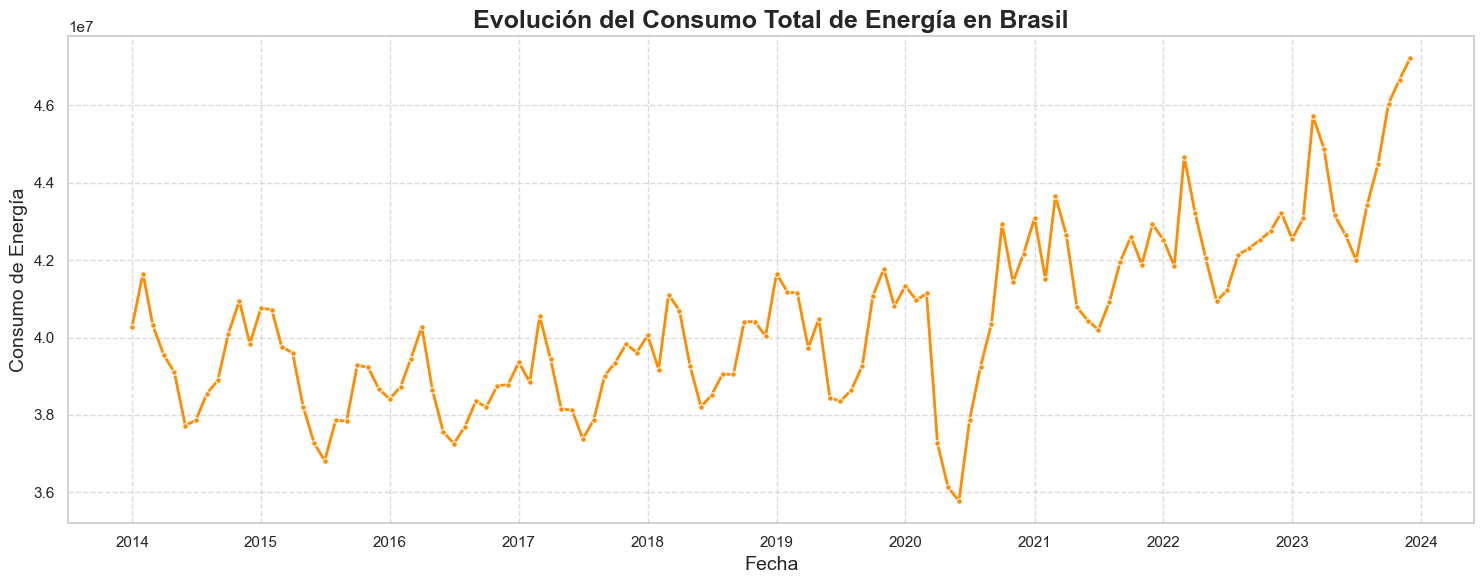

In [7]:
# 1. Agrupar los datos: Sumamos el consumo de todos los estados y sectores por cada fecha
consumo_nacional = df_brasil.groupby(df_brasil.index)['Consumo'].sum()

# 2. Configurar el tamaño del lienzo
plt.figure(figsize=(15, 6))

# 3. Crear el gráfico de línea de tiempo
sns.lineplot(x=consumo_nacional.index, y=consumo_nacional.values, color='darkorange', linewidth=2, marker='o', markersize=4)

# 4. Personalizar textos y estilo
plt.title('Evolución del Consumo Total de Energía en Brasil', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Consumo de Energía', fontsize=14)

# Añadimos una cuadrícula punteada para leer mejor los picos
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Análisis del gráfico.
Se observa que el consumo en Brasil ha seguido una tendencia alcista durante el periodo analizado, lo que refleja un crecimiento constante en la demanda del país. Sin embargo, el momento más impactante ocurre en 2020, donde se ve una caída brusca y profunda causada por el freno de la pandemia. Luego de ese golpe, el país no solo se recuperó rápido, sino que para 2023 alcanzó niveles récord en el consumo. Además, los constantes 'sube y baja' que se repiten cada año nos muestran cómo el clima (como el calor del verano) marca el ritmo del consumo. A este patrón se lo conoce como comportamiento estacional.

### Análisis Temporal y Regional Detallado

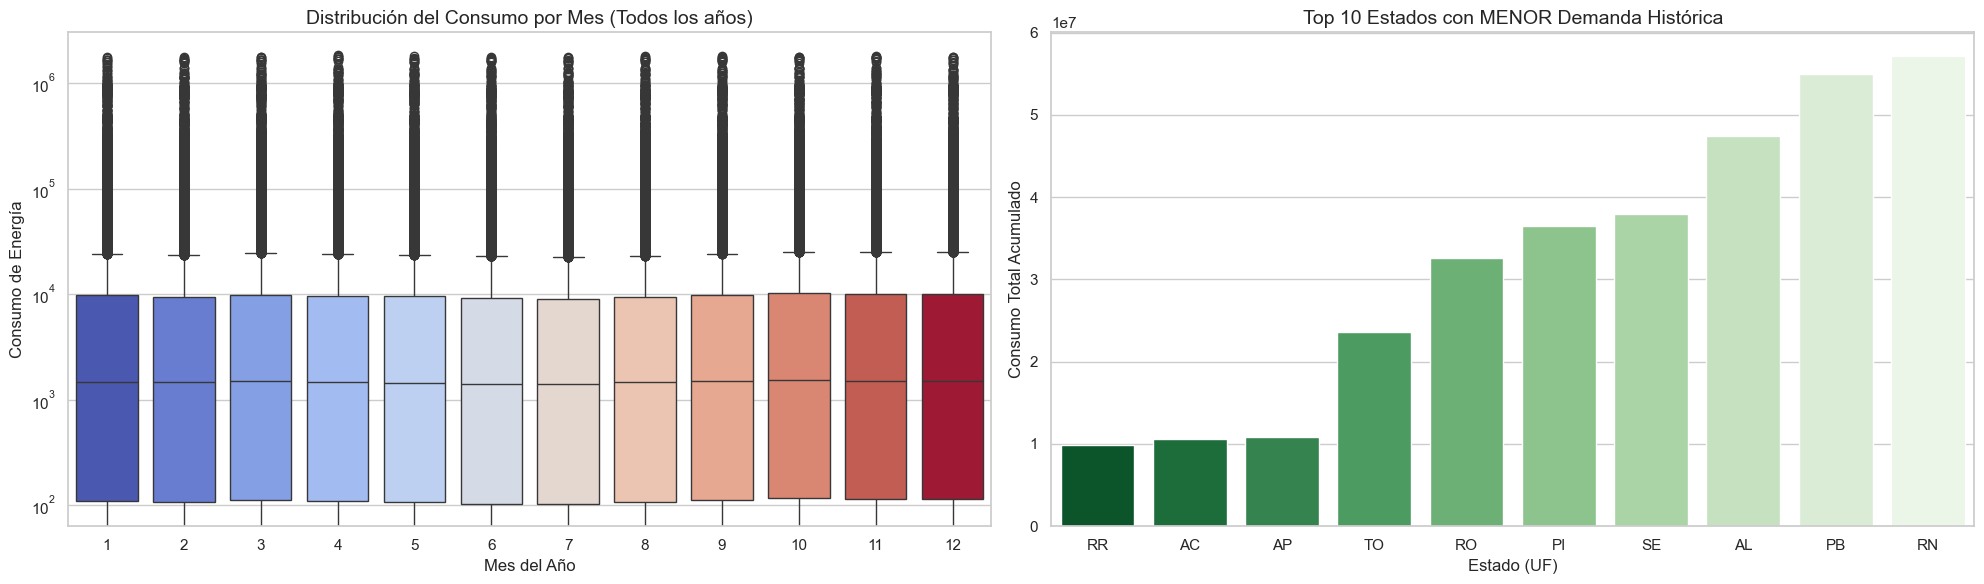

In [15]:
from matplotlib.pyplot import legend
# 1. Extraer el Mes y el Año del índice temporal para agrupar
df_brasil['Mes'] = df_brasil.index.month
df_brasil['Ano'] = df_brasil.index.year

# Configuramos una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(20,6))

# --- GRÁFICO 1: Estacionalidad Mensual ---
# Usamos un boxplot para ver cómo se comporta cada mes a lo largo de todos los años
sns.boxplot(data=df_brasil, x='Mes', y='Consumo', ax=axes[0], palette='coolwarm', hue='Mes', legend=False)
axes[0].set_title('Distribución del Consumo por Mes (Todos los años)', fontsize=14)
axes[0].set_xlabel('Mes del Año', fontsize=12)
axes[0].set_ylabel('Consumo de Energía', fontsize=12)
axes[0].set_yscale('log')

# --- GRÁFICO 2: Demanda por Estado (UF - Unidade Federativa) ---
# Sumamos el consumo histórico por estado y tomamos los 10 con MENOR consumo (nuestros candidatos)
consumo_por_estado = df_brasil.groupby('UF')['Consumo'].sum().sort_values()
# Tomamos los 10 estados con menos consumo
estados_baja_demanda = consumo_por_estado.head(10)

sns.barplot(x=estados_baja_demanda.index, y=estados_baja_demanda.values, ax=axes[1], palette='Greens_r', hue=estados_baja_demanda.index, legend=False)
axes[1].set_title('Top 10 Estados con MENOR Demanda Histórica', fontsize=14)
axes[1].set_xlabel('Estado (UF)', fontsize=12)
axes[1].set_ylabel('Consumo Total Acumulado', fontsize=12)

plt.tight_layout()
plt.show()